# 04a - Rollout Capacity Sweep

A focused sweep over rollout horizon, latent dimension, and number of training networks. Frames per network are held constant so the plots isolate rollout capacity.

In [1]:
from __future__ import annotations

import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from lss.latent.capacity import build_capacity_specs, run_capacity_sweep
from lss.latent.experiment import seed_everything
from lss.utils import resolve_device

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 9,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
})

/home/alexz/Documents/course_project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

In [2]:
seed = random.SystemRandom().randrange(1, 2**31)
seed_everything(seed)
print('run seed:', seed)

selected_dataset = 'depablo-10k-mix-temp'

dataset_specs = {
    'reid': {
        'label': 'Reid',
        'path': '../../data/new_reid_combined.pt',
        'train_count': 50,
        'val_count': 20,
    },
    'depablo': {
        'label': 'dePablo',
        'path': '../../data/2340_dePablo_networks_OOL_undirected.pt',
        'train_count': 30,
        'val_count': 25,
    },
    'depablo-10k-mix-temp': {
        'label': 'dePablo 10k mixed temperature',
        'path': 'data/depablo-10k-mix-temp.pt',
        'train_count': 20,
        'val_count': 50,
    },
}

# Small rollout-focused sweep.
latent_dims = [1, 2, 4, 8]
train_counts = [2, 10, 20, 50, 100]
train_frames_per_network = [20, 50, 100, 150]
rollout_steps = list(range(10, 190, 10))
repeats = 1

cfg = {
    'split_seed': seed,
    'min_train_p_ratio': None,
    'device': 'auto',
    'pos_dim': 2,
    'batch_graphs': 4,
    'frame_skip': 1,
    # Include the undeformed state because every rollout starts from frame 0.
    'train_frame_start_order': 0,
    'latent_tokens': 16,
    'hidden_size': 192,
    'edge_feature_dim': 8,
    'ae_target_mode': 'delta',
    'node_feature_mode': 'delta',
    # Preserve the transverse response that controls the p-ratio.
    'ae_coordinate_weights': [1.0, 2.0],
    'ae_max_epochs': 300,
    'ae_patience': 5,
    'ae_lr': 1e-4,
    'ae_weight_decay': 1e-5,
    'dyn_max_epochs': 300,
    'dyn_patience': 5,
    'dyn_lr': 1e-4,
    'dyn_weight_decay': 1e-5,
    'propagator_loss': 'delta',
    'propagator_objective': 'one_step',
    # Condition every latent update on reference geometry, topology and stiffness.
    'propagator_use_static_context': True,
    'graph_context_dim': 16,
    'propagator_context_include_temperature': False,
    'propagator_step_stride': 1,
    'initial_velocity': 'zero',
    'propagator_model': None,
    'early_stop_min_delta': 1e-5,
    'rollout_steps_grid': rollout_steps,
    'temperature_pratio_window': 'full',
    'output_root': '../results/latent_rollout_capacity_sweep',
}

device = resolve_device(cfg['device'])
run_dir = Path(cfg['output_root']) / selected_dataset
sweep_specs = build_capacity_specs(
    [selected_dataset],
    dataset_specs,
    cfg,
    latent_dims=latent_dims,
    train_counts=train_counts,
    train_frame_counts=train_frames_per_network,
    target_modes=['delta'],
    repeats=repeats,
    seed=seed,
)

print('dataset:', selected_dataset)
print('device:', device)
print('configurations:', len(latent_dims) * len(train_counts) * len(train_frames_per_network))
print('total runs:', len(sweep_specs))
print('rollout horizons:', rollout_steps)
print('output:', run_dir)

run seed: 1669065223
dataset: depablo-10k-mix-temp
device: cuda
configurations: 80
total runs: 80
rollout horizons: [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180]
output: ../results/latent_rollout_capacity_sweep/depablo-10k-mix-temp


## Train Or Load Models

In [ ]:
sweep_tables = run_capacity_sweep(
    sweep_specs,
    cfg,
    device=device,
    output_dir=run_dir,
    force_training=True,
    collect_initial_latents=False,
)

rollout_raw_df = sweep_tables['rollout_raw']
rollout_stats_df = sweep_tables['rollout_stats']
model_manifest_df = sweep_tables['model_manifest']

print('saved/loaded models:', len(model_manifest_df))
display(model_manifest_df.head())

[1/80] depablo-10k-mix-temp_delta_cv01_nets002_frames020_rep01.pt

=== dePablo 10k mixed temperature CV1 delta ===
              source                                                              path  total  train  val  test
depablo-10k-mix-temp /home/alexz/Documents/course_project/data/depablo-10k-mix-temp.pt    300      2   50   248
autoencoder
ae 0001 train=0.994977 val=0.522216 stale=0
ae 0002 train=0.981522 val=0.520908 stale=0
latent propagator: objective=one_step step_stride=1 train_rows=40 val_rows=1000
propagator 0001 train=1.10805 val=2.83462 stale=0
rollout eval split=train: 18 horizons up to 180
rollout eval split=val: 18 horizons up to 180
rollout eval split=test: 18 horizons up to 180
[2/80] depablo-10k-mix-temp_delta_cv01_nets002_frames050_rep01.pt

=== dePablo 10k mixed temperature CV1 delta ===
              source                                                              path  total  train  val  test
depablo-10k-mix-temp /home/alexz/Documents/course_project/data/

## Rollout R2 And Position MSE

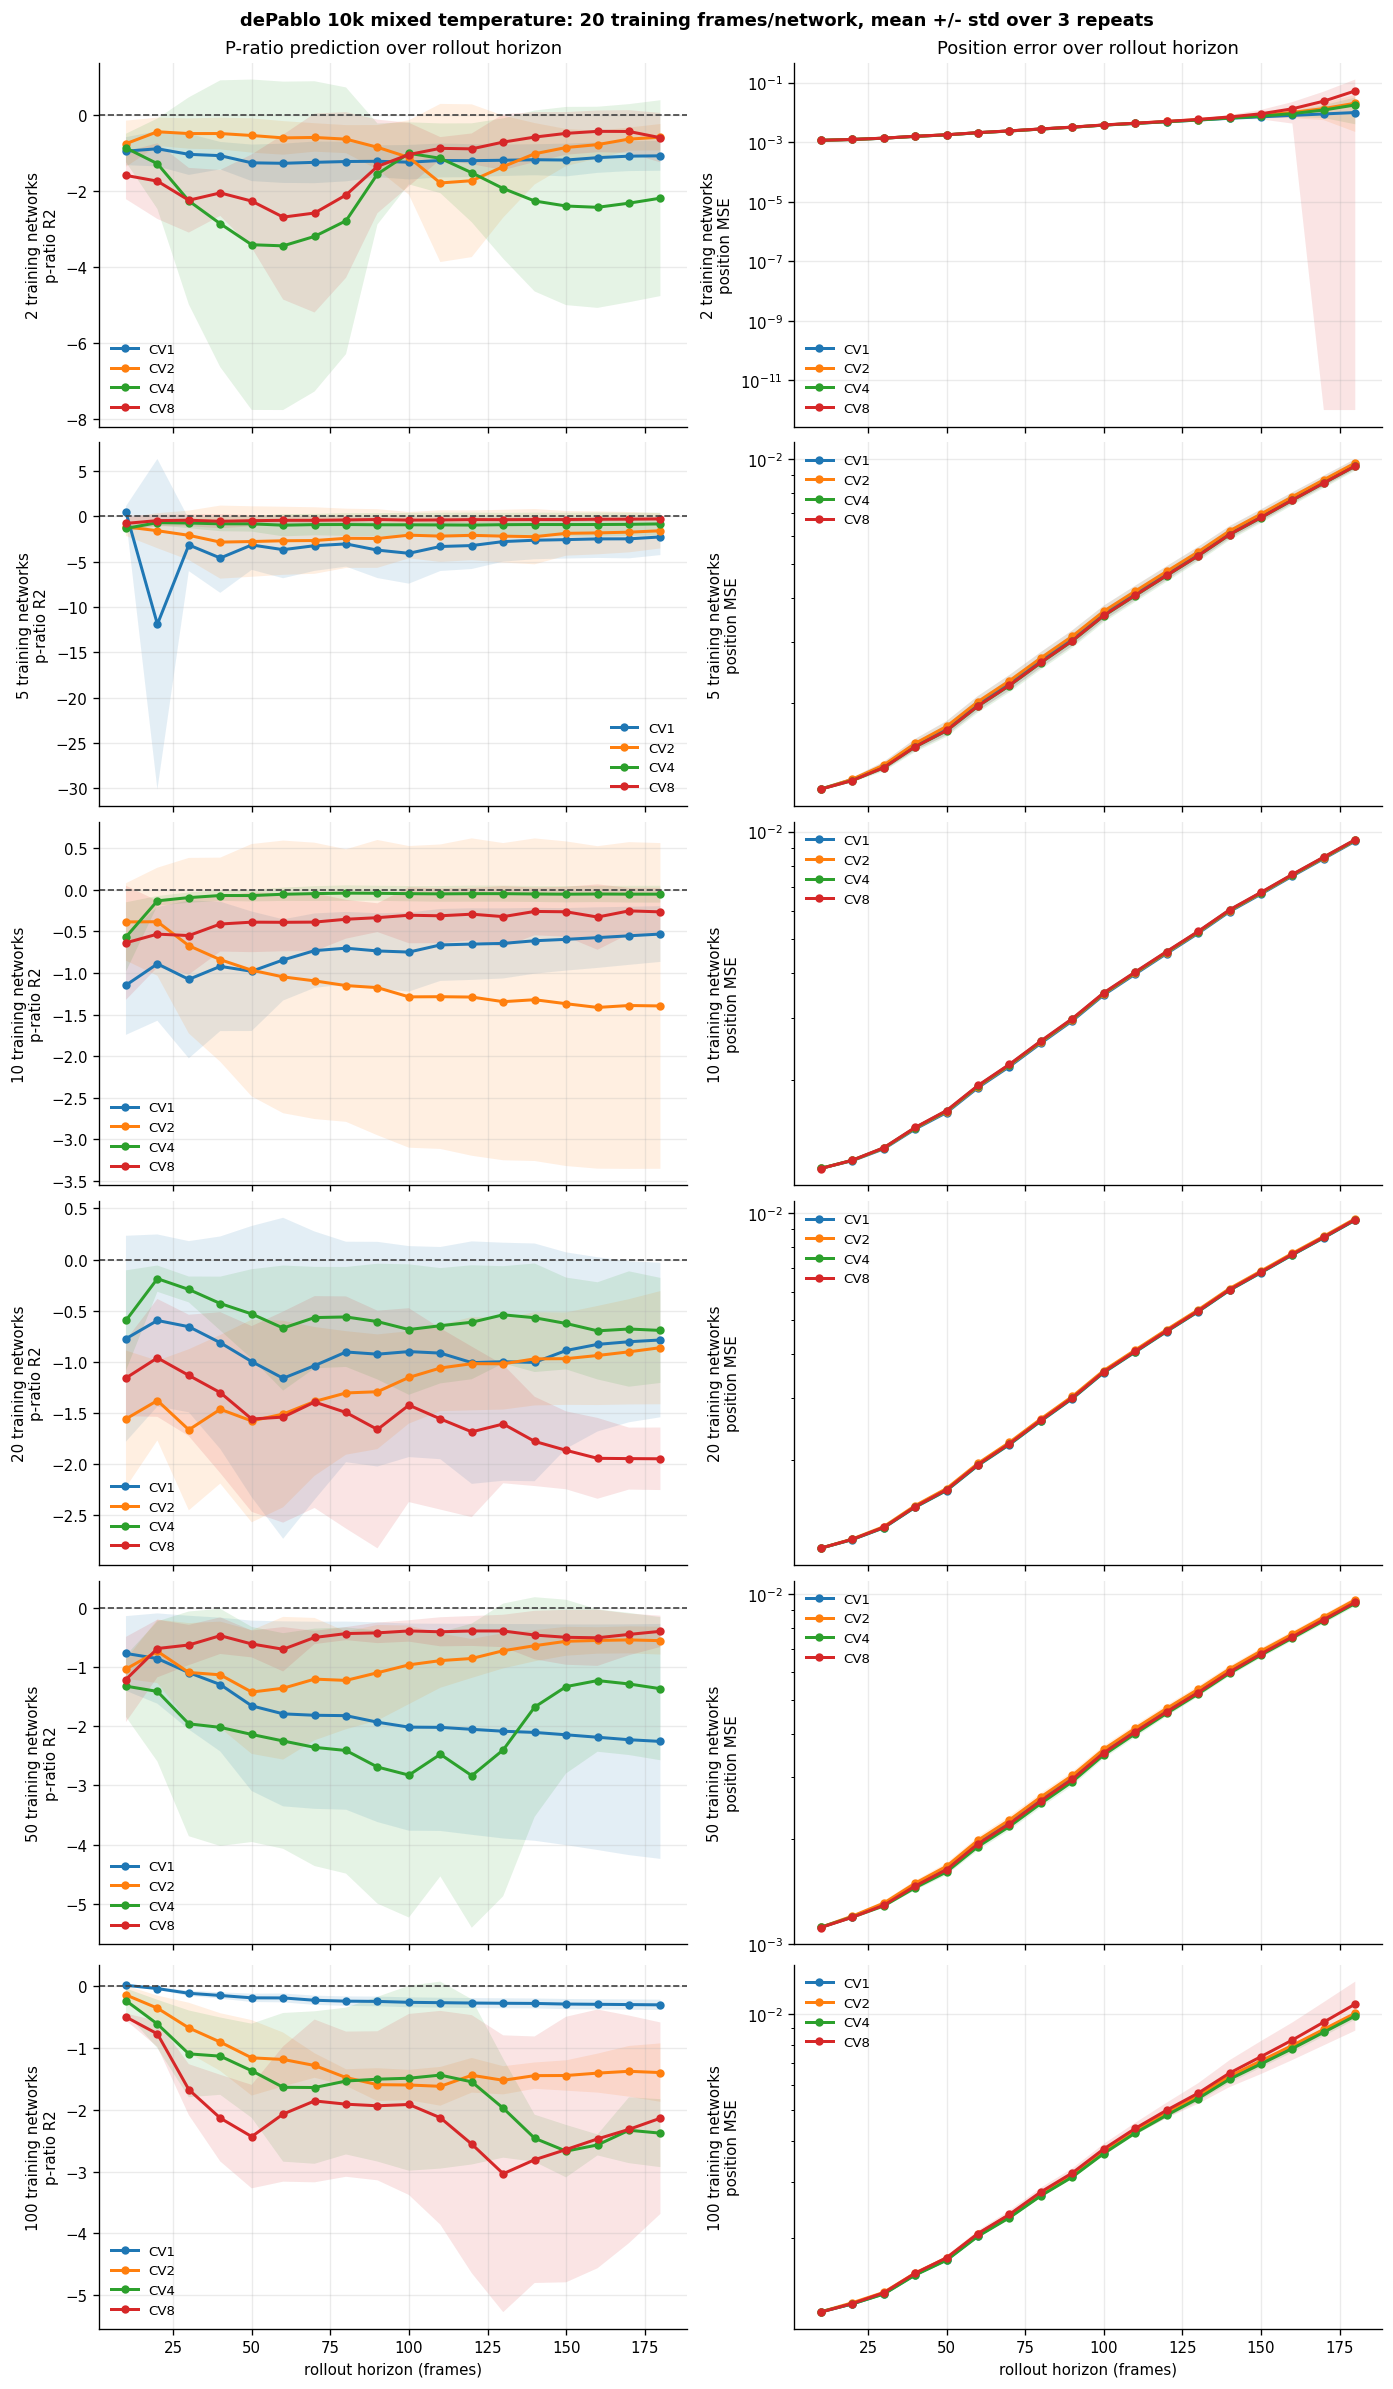

,train_networks,latent_dim,rollout_steps,p_ratio_r2_mean,p_ratio_r2_std,position_mse_mean,position_mse_std,n_repeats
0,2,1,10,-0.945456,0.368000,0.001146,0.000002,3
1,2,1,20,-0.882494,0.462692,0.001226,0.000003,3
2,2,1,30,-1.028485,0.541165,0.001353,0.000006,3
3,2,1,40,-1.063699,0.360475,0.001563,0.000009,3
4,2,1,50,-1.252058,0.479782,0.001753,0.000012,3
...,...,...,...,...,...,...,...,...
427,100,8,140,-2.807749,1.997717,0.006532,0.000628,3
428,100,8,150,-2.642638,2.151859,0.007348,0.000865,3
429,100,8,160,-2.470525,2.096573,0.008280,0.001107,3
430,100,8,170,-2.315771,1.844390,0.009416,0.001447,3


In [ ]:
test_stats = rollout_stats_df[rollout_stats_df['split'].eq('test')].copy()
rollout_summary_df = (
    test_stats
    .groupby(
        ['train_networks', 'train_frames_per_network', 'latent_dim', 'rollout_steps'],
        as_index=False,
    )
    .agg(
        p_ratio_r2_mean=('p_ratio_r2', 'mean'),
        p_ratio_r2_std=('p_ratio_r2', 'std'),
        position_mse_mean=('final_pos_mse', 'mean'),
        position_mse_std=('final_pos_mse', 'std'),
        n_repeats=('repeat_idx', 'nunique'),
    )
)
rollout_summary_df[['p_ratio_r2_std', 'position_mse_std']] = rollout_summary_df[
    ['p_ratio_r2_std', 'position_mse_std']
].fillna(0.0)
rollout_summary_df.to_csv(run_dir / 'rollout_capacity_summary.csv', index=False)

for frame_count in train_frames_per_network:
    fig, axes = plt.subplots(
        len(train_counts), 2,
        figsize=(11.5, 3.3 * len(train_counts)),
        sharex=True,
        squeeze=False,
        constrained_layout=True,
    )

    frame_df = rollout_summary_df[
        rollout_summary_df['train_frames_per_network'].eq(frame_count)
    ]
    for row_idx, network_count in enumerate(train_counts):
        network_df = frame_df[frame_df['train_networks'].eq(network_count)]
        for latent_dim, group in network_df.groupby('latent_dim'):
            group = group.sort_values('rollout_steps')
            label = f'CV{int(latent_dim)}'
            x = group['rollout_steps'].to_numpy(float)

            r2 = group['p_ratio_r2_mean'].to_numpy(float)
            r2_std = group['p_ratio_r2_std'].to_numpy(float)
            axes[row_idx, 0].plot(x, r2, marker='o', lw=1.8, ms=4, label=label)
            axes[row_idx, 0].fill_between(x, r2 - r2_std, r2 + r2_std, alpha=0.12)

            mse = group['position_mse_mean'].to_numpy(float)
            mse_std = group['position_mse_std'].to_numpy(float)
            axes[row_idx, 1].plot(x, mse, marker='o', lw=1.8, ms=4, label=label)
            axes[row_idx, 1].fill_between(
                x,
                np.maximum(mse - mse_std, 1e-12),
                mse + mse_std,
                alpha=0.12,
            )

        axes[row_idx, 0].axhline(0, color='0.25', lw=1, ls='--')
        axes[row_idx, 0].set_ylabel(f'{network_count} training networks\np-ratio R2')
        axes[row_idx, 1].set_ylabel(f'{network_count} training networks\nposition MSE')
        axes[row_idx, 1].set_yscale('log')
        for ax in axes[row_idx]:
            ax.legend(frameon=False, fontsize=8)

    axes[0, 0].set_title('P-ratio prediction over rollout horizon')
    axes[0, 1].set_title('Position error over rollout horizon')
    axes[-1, 0].set_xlabel('rollout horizon (frames)')
    axes[-1, 1].set_xlabel('rollout horizon (frames)')
    fig.suptitle(
        f'{dataset_specs[selected_dataset]["label"]}: {frame_count} training frames/network, '
        f'mean +/- std over {repeats} repeats',
        fontweight='bold',
    )
    plt.show()

display(rollout_summary_df.round(6))

## Best Configuration At Each Horizon

In [ ]:
best_r2_df = (
    rollout_summary_df
    .sort_values(
        ['rollout_steps', 'p_ratio_r2_mean', 'latent_dim', 'train_networks', 'train_frames_per_network'],
        ascending=[True, False, True, True, True],
    )
    .drop_duplicates('rollout_steps')
)

best_position_df = (
    rollout_summary_df
    .sort_values(
        ['rollout_steps', 'position_mse_mean', 'latent_dim', 'train_networks', 'train_frames_per_network'],
        ascending=[True, True, True, True, True],
    )
    .drop_duplicates('rollout_steps')
)

print('Best p-ratio rollout by horizon')
display(best_r2_df[[
    'rollout_steps', 'latent_dim', 'train_networks', 'train_frames_per_network',
    'p_ratio_r2_mean', 'p_ratio_r2_std',
    'position_mse_mean', 'n_repeats',
]].round(6))

print('Lowest position MSE by horizon')
display(best_position_df[[
    'rollout_steps', 'latent_dim', 'train_networks', 'train_frames_per_network',
    'position_mse_mean', 'position_mse_std',
    'p_ratio_r2_mean', 'n_repeats',
]].round(6))

Best p-ratio rollout by horizon


,rollout_steps,latent_dim,train_networks,p_ratio_r2_mean,p_ratio_r2_std,position_mse_mean,n_repeats
72,10,1,5,0.455236,0.660681,0.001135,3
361,20,1,100,-0.033924,0.022936,0.001247,3
182,30,4,10,-0.093605,0.062222,0.001292,3
183,40,4,10,-0.068421,0.064339,0.001472,3
184,50,4,10,-0.069077,0.070407,0.001641,3
185,60,4,10,-0.053370,0.080073,0.001930,3
186,70,4,10,-0.045572,0.089158,0.002212,3
187,80,4,10,-0.039805,0.092791,0.002573,3
188,90,4,10,-0.041913,0.090305,0.002973,3
189,100,4,10,-0.046149,0.091815,0.003515,3


Lowest position MSE by horizon


,rollout_steps,latent_dim,train_networks,position_mse_mean,position_mse_std,p_ratio_r2_mean,n_repeats
342,10,8,50,0.001116,0.000001,-1.211678,3
145,20,1,10,0.001190,0.000001,-0.890694,3
146,30,1,10,0.001284,0.000002,-1.076868,3
327,40,4,50,0.001450,0.000024,-2.019761,3
328,50,4,50,0.001610,0.000034,-2.139156,3
329,60,4,50,0.001902,0.000047,-2.249161,3
330,70,4,50,0.002171,0.000055,-2.356537,3
331,80,4,50,0.002526,0.000067,-2.409883,3
332,90,4,50,0.002915,0.000077,-2.689024,3
333,100,4,50,0.003477,0.000083,-2.825492,3
